In [1]:
#!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import os
import json
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

# Set plot style
sns.set(style="whitegrid")

# Define paths
BASE_DIR = r"d:\Workspace\Thesis\Sumobot Logs 3060"
LOGS_DIR = os.path.join(BASE_DIR, "Logs")
TRAINING_DATA_DIR = os.path.join(BASE_DIR, "TrainingData")
CSV_FILE = os.path.join(BASE_DIR, "selected_logs.csv")

In [3]:
# Update PyTorch to version compatible with RTX 5090 (CUDA 12.8+)
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

In [4]:
# Verify System Capabilities (GPU)
import sys
print("System Configuration Check:")

# 1. Check for GPU (PyTorch/TensorFlow)
gpu_available = False
try:
    import torch
    if torch.cuda.is_available():
        print(f"  ✅ GPU Available (PyTorch): {torch.cuda.get_device_name(0)}")
        gpu_available = True
except ImportError:
    pass

if not gpu_available:
    try:
        import tensorflow as tf
        gpus = tf.config.list_physical_devices('GPU')
        if gpus:
            print(f"  ✅ GPU Available (TensorFlow): {len(gpus)} device(s)")
            gpu_available = True
    except ImportError:
        pass

if not gpu_available:
    print("  ⚠️ No GPU detected or libraries not installed.")

# 2. Check for GPU DataFrame support
try:
    import cudf
    print("  ✅ RAPIDS cuDF available (GPU-accelerated DataFrames).")
except ImportError:
    if sys.platform == "win32":
        print("  ℹ️ RAPIDS cuDF not found (Not supported on native Windows, requires WSL2).")
        print("     Data analysis will run on CPU (Standard Pandas).")
    else:
        print("  ℹ️ RAPIDS cuDF not found. Data analysis will run on CPU (Standard Pandas).")

System Configuration Check:
  ✅ GPU Available (PyTorch): NVIDIA GeForce RTX 5090
  ℹ️ RAPIDS cuDF not found (Not supported on native Windows, requires WSL2).
     Data analysis will run on CPU (Standard Pandas).


In [5]:
# Process all folders in Logs and create individual CSV files
print(f"Processing folders in {LOGS_DIR}...")

for folder_name in os.listdir(LOGS_DIR):
    folder_path = os.path.join(LOGS_DIR, folder_name)
    
    if not os.path.isdir(folder_path):
        continue
        
    # List all game JSON files
    game_files = glob.glob(os.path.join(folder_path, "game_*.json"))
    
    if not game_files:
        continue
        
    folder_game_data = []
    
    # Try to load metadata for bot names if available
    metadata_path = os.path.join(folder_path, "metadata.json")
    left_bot = "Unknown"
    right_bot = "Unknown"
    
    if os.path.exists(metadata_path):
        try:
            with open(metadata_path, 'r', encoding='utf-8') as f:
                metadata = json.load(f)
                left_bot = metadata.get("LeftPlayerStats", {}).get("Bot", "Unknown")
                right_bot = metadata.get("RightPlayerStats", {}).get("Bot", "Unknown")
        except:
            pass

    for game_file in game_files:
        try:
            with open(game_file, 'r', encoding='utf-8') as f:
                game_data = json.load(f)
            
            # Game Level Info
            game_index = game_data.get("Index")
            game_timestamp = game_data.get("Timestamp")
            game_winner = game_data.get("Winner")
            
            rounds = game_data.get("Rounds", [])
            
            for rnd in rounds:
                # Round Level Info
                round_index = rnd.get("Index")
                round_timestamp = rnd.get("Timestamp")
                round_winner = rnd.get("Winner")
                round_duration = rnd.get("Duration")
                
                events = rnd.get("PlayerEvents", [])
                
                for evt in events:
                    # Event Level Info
                    row = {
                        "GameIndex": game_index,
                        "GameTimestamp": game_timestamp,
                        "GameWinner": game_winner,
                        "Meta_LeftBot": left_bot,
                        "Meta_RightBot": right_bot,
                        "RoundIndex": round_index,
                        "RoundTimestamp": round_timestamp,
                        "RoundWinner": round_winner,
                        "RoundDuration": round_duration,
                        "Event_StartedAt": evt.get("StartedAt"),
                        "Event_UpdatedAt": evt.get("UpdatedAt"),
                        "Event_Actor": evt.get("Actor"),
                        "Event_Target": evt.get("Target"),
                        "Event_Duration": evt.get("Duration"),
                        "Event_Category": evt.get("Category"),
                        "Event_State": evt.get("State"),
                    }
                    
                    # Data Level Info
                    data = evt.get("Data")
                    if data and isinstance(data, dict):
                        row["Event_Data_Name"] = data.get("Name")
                        row["Event_Data_Duration"] = data.get("Duration")
                        row["Event_Data_Reason"] = data.get("Reason")
                        
                        # Helper to extract velocity
                        def get_velocity(robot_data):
                            if not robot_data or not isinstance(robot_data, dict):
                                return None
                            val = robot_data.get("LinearVelocity")
                            if isinstance(val, (int, float)):
                                return float(val)
                            if isinstance(val, dict):
                                # Calculate magnitude if X/Y provided
                                x = val.get("X", 0)
                                y = val.get("Y", 0)
                                return (x**2 + y**2)**0.5
                            return None

                        # Robot Info
                        robot = data.get("Robot")
                        if robot and isinstance(robot, dict):
                            row["Robot_AngularVelocity"] = robot.get("AngularVelocity")
                            row["Robot_Rotation"] = robot.get("Rotation")
                            row["Robot_LinearVelocity"] = get_velocity(robot)
                            
                            pos = robot.get("Position")
                            if pos and isinstance(pos, dict):
                                row["Robot_PosX"] = pos.get("X")
                                row["Robot_PosY"] = pos.get("Y")
                            
                            lin_vel = robot.get("LinearVelocity")
                            if lin_vel and isinstance(lin_vel, dict):
                                row["Robot_LinVelX"] = lin_vel.get("X")
                                row["Robot_LinVelY"] = lin_vel.get("Y")
                        
                        # Enemy Robot Info (For Collisions & Distance)
                        enemy_robot = data.get("EnemyRobot")
                        if enemy_robot and isinstance(enemy_robot, dict):
                             row["EnemyRobot_LinearVelocity"] = get_velocity(enemy_robot)
                             
                             e_pos = enemy_robot.get("Position")
                             if e_pos and isinstance(e_pos, dict):
                                 row["EnemyRobot_PosX"] = e_pos.get("X")
                                 row["EnemyRobot_PosY"] = e_pos.get("Y")

                    folder_game_data.append(row)
                
        except Exception as e:
            print(f"Error processing {game_file}: {e}")
            
    if folder_game_data:
        df_folder = pd.DataFrame(folder_game_data)
        csv_path = os.path.join(folder_path, "game_logs.csv")
        df_folder.to_csv(csv_path, index=False)
        # print(f"Created {csv_path} with {len(df_folder)} records.") 

print("Done processing Logs folders. Created game_logs.csv in each folder.")

Processing folders in d:\Workspace\Thesis\Sumobot Logs 3060\Logs...
Done processing Logs folders. Created game_logs.csv in each folder.


In [6]:
# Merge all game_logs.csv files into a single dataset
print("Merging all game_logs.csv files...")

all_logs = []

# Define Bot Name Mapping
bot_mapping = {
    "NeuralBot": "Bot_NN",
    "Bot_NN": "Bot_NN",
    "AIBot_NN": "Bot_NN",
    "QLearningBot": "Bot_DQN",
    "Bot_DQN": "Bot_DQN",
    "AIBot_DQN": "Bot_DQN",
    "PPOBot": "Bot_PPO",
    "AIBot_PPO": "Bot_PPO",
    "Bot_PPO": "Bot_PPO",
    "LSTMBot": "Bot_LSTM",
    "Bot_LSTM": "Bot_LSTM",
    "AIBot_LSTM": "Bot_LSTM"
}

target_bots = ["Bot_NN", "Bot_DQN", "Bot_PPO"] # LSTM

for folder_name in os.listdir(LOGS_DIR):
    folder_path = os.path.join(LOGS_DIR, folder_name)
    csv_path = os.path.join(folder_path, "game_logs.csv")
    metadata_path = os.path.join(folder_path, "metadata.json")
    
    if os.path.exists(csv_path):
        try:
            # Read the individual CSV
            df_log = pd.read_csv(csv_path)
            
            # Normalize Bot Names
            def get_normalized_name(name):
                return bot_mapping.get(name, name)

            if "Meta_LeftBot" in df_log.columns:
                df_log["Meta_LeftBot"] = df_log["Meta_LeftBot"].apply(get_normalized_name)
            if "Meta_RightBot" in df_log.columns:
                df_log["Meta_RightBot"] = df_log["Meta_RightBot"].apply(get_normalized_name)

            # Filter: Keep if EITHER bot is in our target list
            mask = df_log["Meta_LeftBot"].isin(target_bots) | df_log["Meta_RightBot"].isin(target_bots)
            df_log_filtered = df_log[mask]
            
            if df_log_filtered.empty:
                continue

            # Add identifying columns
            df_log_filtered = df_log_filtered.copy()
            df_log_filtered["Folder"] = folder_name
            
            # Try to get BattleID from metadata
            battle_id = "Unknown"
            if os.path.exists(metadata_path):
                try:
                    with open(metadata_path, 'r', encoding='utf-8') as f:
                        meta = json.load(f)
                        battle_id = meta.get("BattleID", "Unknown")
                except:
                    pass
            
            df_log_filtered["BattleID"] = battle_id
            
            all_logs.append(df_log_filtered)
            
        except Exception as e:
            print(f"Error reading {csv_path}: {e}")

if all_logs:
    merged_df = pd.concat(all_logs, ignore_index=True)
    
    # Reorder columns to make BattleID first
    cols = ["BattleID"] + [c for c in merged_df.columns if c != "BattleID"]
    merged_df = merged_df[cols]
    
    merged_csv_path = os.path.join(BASE_DIR, "game_logs_merged.csv")
    merged_df.to_csv(merged_csv_path, index=False)
    print(f"Successfully created {merged_csv_path}")
    print(f"Total records: {len(merged_df)}")
    
    # Print unique bots found in the merged data to verify
    unique_bots = set(merged_df["Meta_LeftBot"].unique()) | set(merged_df["Meta_RightBot"].unique())
    print(f"Unique bots in merged data: {unique_bots}")
else:
    print("No matching game_logs.csv files found to merge.")

merged_df.head()

Merging all game_logs.csv files...
Successfully created d:\Workspace\Thesis\Sumobot Logs 3060\game_logs_merged.csv
Total records: 724707
Unique bots in merged data: {'Bot_NN', 'Genetic Algorithm Example', 'Bot_GA', 'Bot_BT', 'Utility AI', 'MCTS Example', 'Bot_DQN', 'Bot_MCTS', 'LSTM', 'FSM_Bot', 'Fuzzy', 'Primitive', 'Bot_PPO', 'BT_Bot'}


,BattleID,GameIndex,GameTimestamp,GameWinner,Meta_LeftBot,Meta_RightBot,RoundIndex,RoundTimestamp,RoundWinner,RoundDuration,...,Robot_Rotation,Robot_LinearVelocity,Robot_PosX,Robot_PosY,Robot_LinVelX,Robot_LinVelY,Folder,EnemyRobot_LinearVelocity,EnemyRobot_PosX,EnemyRobot_PosY
0,6bd04986-d3a1-441b-ad01-8a6ab5d457c1,0,20250801_164559,Left,Bot_NN,Primitive,1,20250801_164559,Left,2.135928,...,-90.0,0.00,-3.300866,2.010163,0.00,0.000000e+00,battle_20250801_164557,NaN,NaN,NaN
1,6bd04986-d3a1-441b-ad01-8a6ab5d457c1,0,20250801_164559,Left,Bot_NN,Primitive,1,20250801_164559,Left,2.135928,...,-90.0,0.00,-3.300866,2.010163,0.00,0.000000e+00,battle_20250801_164557,NaN,NaN,NaN
2,6bd04986-d3a1-441b-ad01-8a6ab5d457c1,0,20250801_164559,Left,Bot_NN,Primitive,1,20250801_164559,Left,2.135928,...,90.0,0.00,3.699134,2.010163,0.00,0.000000e+00,battle_20250801_164557,NaN,NaN,NaN
3,6bd04986-d3a1-441b-ad01-8a6ab5d457c1,0,20250801_164559,Left,Bot_NN,Primitive,1,20250801_164559,Left,2.135928,...,-110.0,3.76,-2.745667,2.010163,3.76,2.241135e-07,battle_20250801_164557,NaN,NaN,NaN
4,6bd04986-d3a1-441b-ad01-8a6ab5d457c1,0,20250801_164559,Left,Bot_NN,Primitive,1,20250801_164559,Left,2.135928,...,-110.0,3.76,-2.745667,2.010163,3.76,2.241135e-07,battle_20250801_164557,NaN,NaN,NaN


In [8]:
# Debug: Check existence of Dash and Skill actions
if 'merged_df' in locals():
    print("--- Unique Action Names in Entire Dataset ---")
    print(merged_df['Event_Data_Name'].unique())
    
    print("\n--- Detailed Counts for Target Bots ---")
    # Filter for our target bots again to see exactly what they are doing
    mask_left = (merged_df["Event_Actor"] == "Left") & (merged_df["Meta_LeftBot"].isin(target_bots))
    mask_right = (merged_df["Event_Actor"] == "Right") & (merged_df["Meta_RightBot"].isin(target_bots))
    
    # Get all raw action names for these bots
    raw_actions = pd.concat([
        merged_df.loc[mask_left, "Event_Data_Name"],
        merged_df.loc[mask_right, "Event_Data_Name"]
    ])
    
    counts = raw_actions.value_counts()
    print(counts)
    
    print("\n--- Check for specific missing keywords ---")
    for keyword in ["Dash", "SkillBoost", "SkillStone"]:
        count = counts.get(keyword, 0)
        print(f"{keyword}: {count}")
else:
    print("merged_df not found. Please run the merge cell first.")

--- Unique Action Names in Entire Dataset ---
['Accelerate' 'TurnRight' 'TurnLeft' 'Dash' nan 'SkillBoost' 'SkillStone']

--- Detailed Counts for Target Bots ---
Event_Data_Name
TurnLeft      158424
Accelerate     88033
TurnRight      74517
Dash           15588
SkillBoost      1828
Name: count, dtype: int64

--- Check for specific missing keywords ---
Dash: 15588
SkillBoost: 1828
SkillStone: 0


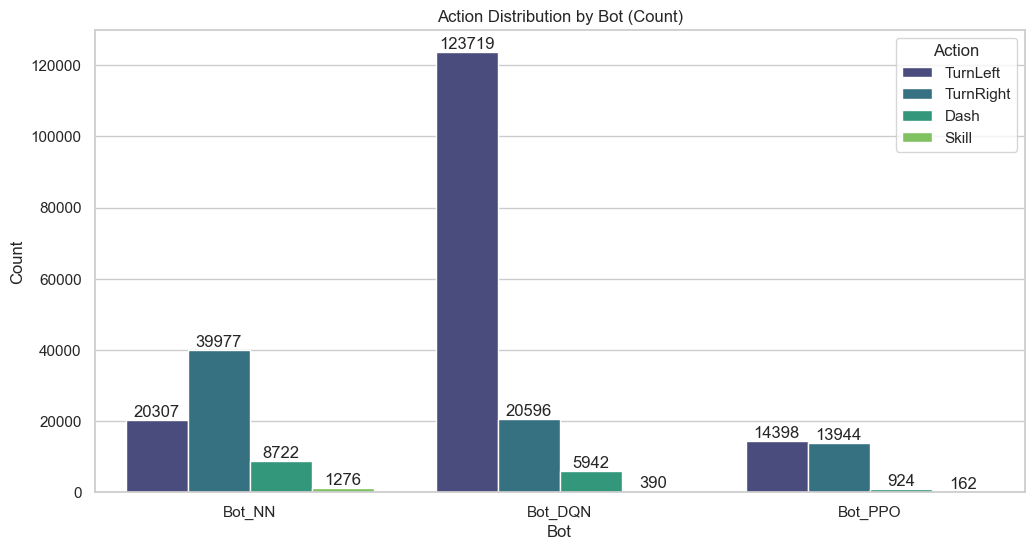

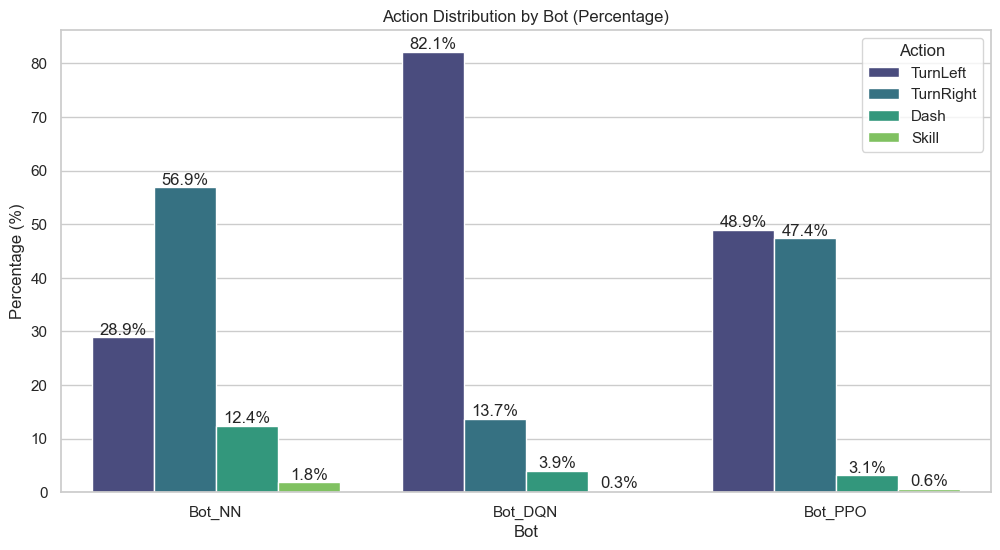

In [9]:
# Action Distribution Analysis
# Load the merged data if not already available
if 'merged_df' not in locals():
    merged_csv_path = os.path.join(BASE_DIR, "game_logs_merged.csv")
    if os.path.exists(merged_csv_path):
        merged_df = pd.read_csv(merged_csv_path)
        print(f"Loaded {len(merged_df)} records from {merged_csv_path}")
    else:
        print("merged_df not found and CSV file missing. Please run the merge cell first.")

if 'merged_df' in locals():
    # Define target bots and action mapping
    target_bots = ["Bot_NN", "Bot_DQN", "Bot_PPO"] # LSTM
    action_mapping = {
        "TurnLeft": "TurnLeft",
        "TurnRight": "TurnRight",
        "Dash": "Dash",
        "SkillBoost": "Skill",
        "SkillStone": "Skill"
    }

    # Filter for actions performed by target bots
    actions_list = []

    # Process Left Actors
    # We want rows where the Actor was 'Left' and the Left Bot was one of our targets
    mask_left = (merged_df["Event_Actor"] == "Left") & (merged_df["Meta_LeftBot"].isin(target_bots))
    df_left = merged_df.loc[mask_left, ["Meta_LeftBot", "Event_Data_Name"]].copy()
    df_left.columns = ["BotType", "Action"]
    actions_list.append(df_left)

    # Process Right Actors
    # We want rows where the Actor was 'Right' and the Right Bot was one of our targets
    mask_right = (merged_df["Event_Actor"] == "Right") & (merged_df["Meta_RightBot"].isin(target_bots))
    df_right = merged_df.loc[mask_right, ["Meta_RightBot", "Event_Data_Name"]].copy()
    df_right.columns = ["BotType", "Action"]
    actions_list.append(df_right)

    # Combine
    if actions_list:
        df_actions = pd.concat(actions_list, ignore_index=True)

        # Map actions and filter
        # This maps the raw action names to the grouped names (e.g. Boost -> Skill)
        # Actions not in the map become NaN and are dropped
        df_actions["Action"] = df_actions["Action"].map(action_mapping)
        df_actions = df_actions.dropna(subset=["Action"])

        # Define orders for consistency
        action_order = ["TurnLeft", "TurnRight", "Dash", "Skill"]
        bot_order = target_bots

        # 1. Plot Raw Counts
        plt.figure(figsize=(12, 6))
        ax1 = sns.countplot(data=df_actions, x="BotType", hue="Action", palette="viridis", 
                            hue_order=action_order, order=bot_order)
        plt.title("Action Distribution by Bot (Count)")
        plt.xlabel("Bot")
        plt.ylabel("Count")
        plt.legend(title="Action")
        
        # Add labels to bars
        for container in ax1.containers:
            ax1.bar_label(container)
            
        plt.show()

        # 2. Plot Normalized Distribution (Percentage)
        # Calculate percentages per bot
        action_counts = df_actions.groupby(['BotType', 'Action']).size().reset_index(name='Count')
        total_counts = df_actions.groupby('BotType').size().reset_index(name='Total')
        action_counts = action_counts.merge(total_counts, on='BotType')
        action_counts['Percentage'] = action_counts['Count'] / action_counts['Total'] * 100

        plt.figure(figsize=(12, 6))
        ax2 = sns.barplot(data=action_counts, x="BotType", y="Percentage", hue="Action", palette="viridis", 
                          hue_order=action_order, order=bot_order)
        plt.title("Action Distribution by Bot (Percentage)")
        plt.xlabel("Bot")
        plt.ylabel("Percentage (%)")
        plt.legend(title="Action")
        
        # Add labels to bars
        for container in ax2.containers:
            ax2.bar_label(container, fmt='%.1f%%')
            
        plt.show()
    else:
        print("No actions found for the target bots.")
else:
    print("Dataframe not available.")

In [10]:
# Debug: Check if LinearVelocity is populated
if 'merged_df' in locals():
    print("Columns:", merged_df.columns)
    print("Robot_LinVelX non-null count:", merged_df["Robot_LinVelX"].count())
    print("Robot_LinVelY non-null count:", merged_df["Robot_LinVelY"].count())
    
    # Check if we have any Collision events
    collision_events = merged_df[merged_df["Event_Category"] == "Collision"]
    print("Collision events count:", len(collision_events))
    if not collision_events.empty:
        print("Sample Collision Event:")
        print(collision_events.iloc[0])
else:
    print("merged_df not found.")

Columns: Index(['BattleID', 'GameIndex', 'GameTimestamp', 'GameWinner', 'Meta_LeftBot',
       'Meta_RightBot', 'RoundIndex', 'RoundTimestamp', 'RoundWinner',
       'RoundDuration', 'Event_StartedAt', 'Event_UpdatedAt', 'Event_Actor',
       'Event_Target', 'Event_Duration', 'Event_Category', 'Event_State',
       'Event_Data_Name', 'Event_Data_Duration', 'Event_Data_Reason',
       'Robot_AngularVelocity', 'Robot_Rotation', 'Robot_LinearVelocity',
       'Robot_PosX', 'Robot_PosY', 'Robot_LinVelX', 'Robot_LinVelY', 'Folder',
       'EnemyRobot_LinearVelocity', 'EnemyRobot_PosX', 'EnemyRobot_PosY'],
      dtype='object')
Robot_LinVelX non-null count: 121630
Robot_LinVelY non-null count: 121630
Collision events count: 79303
Sample Collision Event:
BattleID                     8ca8a719-3e59-45f6-a5c4-d235ea1deaf2
GameIndex                                                       5
GameTimestamp                                     20250801_165307
GameWinner                                  

Games Played per Bot: {'Bot_NN': 61, 'Bot_DQN': 105, 'Bot_PPO': 43}


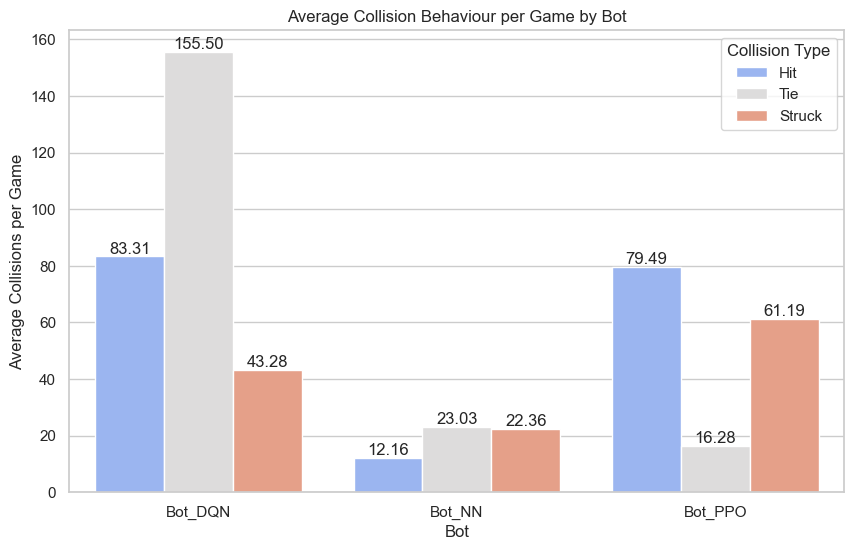

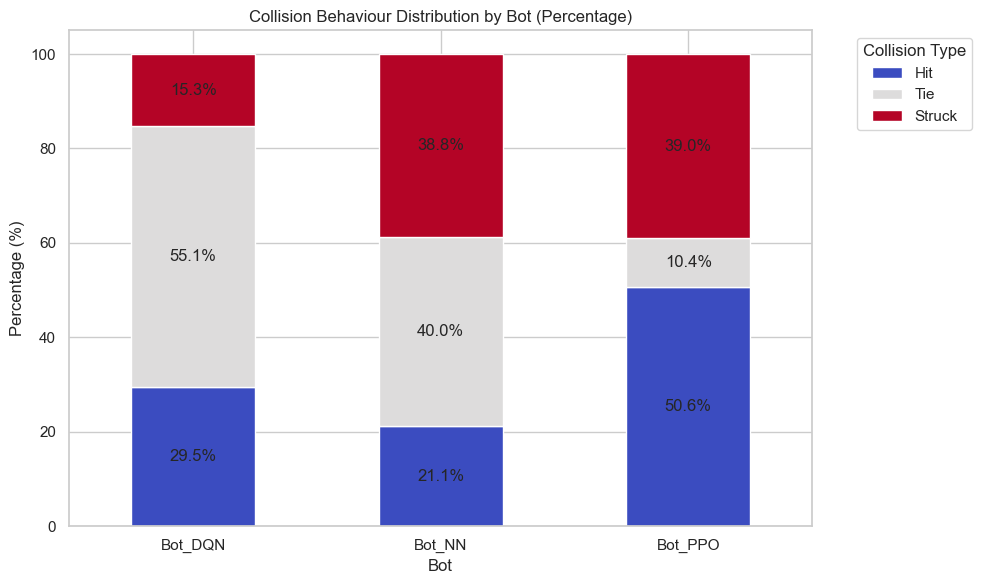

   BotName CollisionType  TotalCount  AveragePerGame
0  Bot_DQN           Hit        8748       83.314286
1  Bot_DQN        Struck        4544       43.276190
2  Bot_DQN           Tie       16328      155.504762
3   Bot_NN           Hit         742       12.163934
4   Bot_NN        Struck        1364       22.360656
5   Bot_NN           Tie        1405       23.032787
6  Bot_PPO           Hit        3418       79.488372
7  Bot_PPO        Struck        2631       61.186047
8  Bot_PPO           Tie         700       16.279070


In [11]:
# Collision Behaviour Analysis
if 'merged_df' in locals():
    # Check if we have the necessary velocity columns
    if "Robot_LinearVelocity" not in merged_df.columns:
        print("⚠️ Missing 'Robot_LinearVelocity' column.")
        print("Please re-run the 'Process all folders' cell (it has been updated to extract velocity) and then re-run the 'Merge' cell.")
    else:
        # Filter for Collision events involving target bots
        target_bots = ["Bot_NN", "Bot_DQN", "Bot_PPO"]
        
        # 1. Calculate Total Games per Bot to compute averages
        # Each folder represents one game
        unique_games = merged_df.drop_duplicates(subset=["Folder"])
        games_played = {bot: 0 for bot in target_bots}
        
        for _, row in unique_games.iterrows():
            if row["Meta_LeftBot"] in games_played:
                games_played[row["Meta_LeftBot"]] += 1
            if row["Meta_RightBot"] in games_played:
                games_played[row["Meta_RightBot"]] += 1
                
        print("Games Played per Bot:", games_played)
        
        # We want events where the Category is Collision and Actor is Left or Right
        mask = (merged_df["Event_Category"] == "Collision") & \
               (merged_df["Event_Actor"].isin(["Left", "Right"]))
        
        df_coll = merged_df[mask].copy()
        
        # Map Actor to BotName
        def get_bot_name(row):
            if row["Event_Actor"] == "Left": return row["Meta_LeftBot"]
            if row["Event_Actor"] == "Right": return row["Meta_RightBot"]
            return "Unknown"
            
        df_coll["BotName"] = df_coll.apply(get_bot_name, axis=1)
        
        # Filter for target bots
        df_coll = df_coll[df_coll["BotName"].isin(target_bots)]
        
        if df_coll.empty:
            print("No collision events found for target bots.")
        else:
            # Determine Collision Type
            # Hit: Actor Vel > Enemy Vel
            # Struck: Actor Vel < Enemy Vel
            # Tie: Equal or missing info
            
            def get_collision_type(row):
                v_actor = row.get("Robot_LinearVelocity")
                v_enemy = row.get("EnemyRobot_LinearVelocity")
                
                if pd.isna(v_actor) or pd.isna(v_enemy):
                    return "Tie" 
                
                # Use a small epsilon for float comparison
                if v_actor > v_enemy + 0.001:
                    return "Hit"
                elif v_actor < v_enemy - 0.001:
                    return "Struck"
                else:
                    return "Tie"
                    
            df_coll["CollisionType"] = df_coll.apply(get_collision_type, axis=1)
            
            # Calculate Totals
            collision_stats = df_coll.groupby(['BotName', 'CollisionType']).size().reset_index(name='TotalCount')
            
            # Calculate Averages
            def calculate_average(row):
                bot = row['BotName']
                total = row['TotalCount']
                n_games = games_played.get(bot, 0)
                return total / n_games if n_games > 0 else 0
                
            collision_stats['AveragePerGame'] = collision_stats.apply(calculate_average, axis=1)
            
            # 1. Plot Average Counts
            plt.figure(figsize=(10, 6))
            ax = sns.barplot(data=collision_stats, x="BotName", y="AveragePerGame", hue="CollisionType", palette="coolwarm", hue_order=["Hit", "Tie", "Struck"])
            plt.title("Average Collision Behaviour per Game by Bot")
            plt.xlabel("Bot")
            plt.ylabel("Average Collisions per Game")
            plt.legend(title="Collision Type")
            
            # Add labels
            for container in ax.containers:
                ax.bar_label(container, fmt='%.2f')
                
            plt.show()

            # 2. Plot Normalized Stacked Bar (Percentage)
            # Pivot for stacking
            collision_pivot = collision_stats.pivot(index='BotName', columns='CollisionType', values='TotalCount').fillna(0)
            
            # Calculate percentages
            collision_pct = collision_pivot.div(collision_pivot.sum(axis=1), axis=0) * 100
            
            # Reorder columns if they exist
            cols_order = [c for c in ["Hit", "Tie", "Struck"] if c in collision_pct.columns]
            collision_pct = collision_pct[cols_order]
            
            # Plot
            ax2 = collision_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='coolwarm')
            plt.title("Collision Behaviour Distribution by Bot (Percentage)")
            plt.xlabel("Bot")
            plt.ylabel("Percentage (%)")
            plt.legend(title="Collision Type", bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.xticks(rotation=0)
            
            # Add labels
            for c in ax2.containers:
                ax2.bar_label(c, fmt='%.1f%%', label_type='center')
                
            plt.tight_layout()
            plt.show()
            
            # Print summary
            print(collision_stats)
        
else:
    print("merged_df not found. Please run the merge cell first.")

Analyzed 559 rounds.


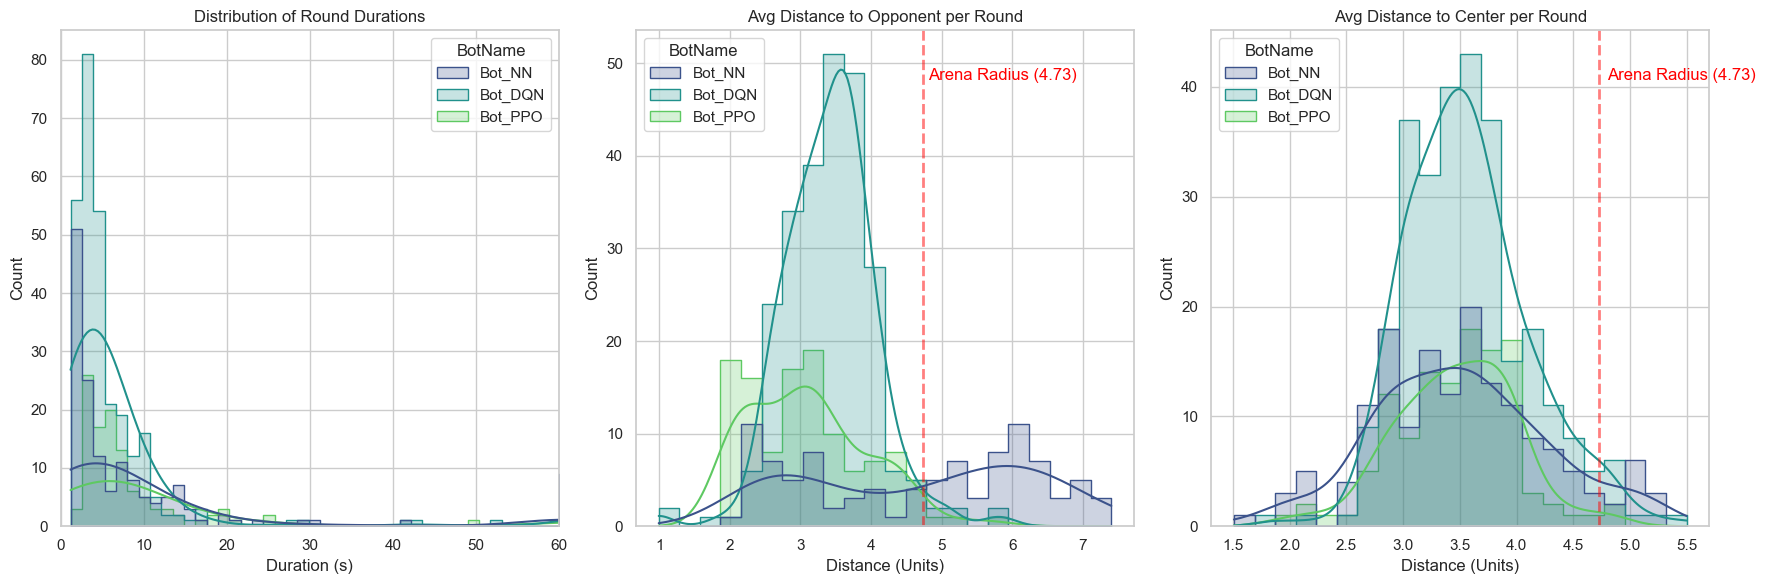

In [12]:
# Spatial and Temporal Analysis
if 'merged_df' in locals():
    # Check for necessary columns
    required_cols = ["Robot_PosX", "Robot_PosY", "EnemyRobot_PosX", "EnemyRobot_PosY", "RoundDuration"]
    missing_cols = [c for c in required_cols if c not in merged_df.columns]
    
    if missing_cols:
        print(f"⚠️ Missing columns: {missing_cols}")
        print("Please re-run the 'Process all folders' cell (updated to extract Enemy Position) and then 'Merge' cell.")
    else:
        target_bots = ["Bot_NN", "Bot_DQN", "Bot_PPO"]
        
        # Filter for target bots
        # We want to analyze the behavior of the Target Bots.
        # So we select rows where the "Robot" corresponds to a Target Bot.
        
        # Case A: Actor is Left, and LeftBot is Target
        mask_left = (merged_df["Event_Actor"] == "Left") & (merged_df["Meta_LeftBot"].isin(target_bots))
        df_left = merged_df[mask_left].copy()
        df_left["BotName"] = df_left["Meta_LeftBot"]
        
        # Case B: Actor is Right, and RightBot is Target
        mask_right = (merged_df["Event_Actor"] == "Right") & (merged_df["Meta_RightBot"].isin(target_bots))
        df_right = merged_df[mask_right].copy()
        df_right["BotName"] = df_right["Meta_RightBot"]
        
        df_spatial = pd.concat([df_left, df_right])
        
        # Calculate Distances
        # Distance to Center (0,0)
        df_spatial["DistToCenter"] = (df_spatial["Robot_PosX"]**2 + df_spatial["Robot_PosY"]**2)**0.5
        
        # Distance to Enemy
        df_spatial["DistToEnemy"] = ((df_spatial["Robot_PosX"] - df_spatial["EnemyRobot_PosX"])**2 + 
                                     (df_spatial["Robot_PosY"] - df_spatial["EnemyRobot_PosY"])**2)**0.5
                                     
        # Group by Round to get Averages per Round
        # Unique identifier for a round: Folder + RoundIndex
        # We take the mean of distances, and the first value of duration (since it's constant for the round)
        round_stats = df_spatial.groupby(["Folder", "RoundIndex", "BotName"]).agg({
            "DistToCenter": "mean",
            "DistToEnemy": "mean",
            "RoundDuration": "first" 
        }).reset_index()
        
        print(f"Analyzed {len(round_stats)} rounds.")
        
        # Plotting
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # 1. Round Duration Distribution
        sns.histplot(data=round_stats, x="RoundDuration", hue="BotName", kde=True, element="step", ax=axes[0], palette="viridis")
        axes[0].set_title("Distribution of Round Durations")
        axes[0].set_xlabel("Duration (s)")
        axes[0].set_xlim(0, 60)
        
        # 2. Average Distance to Enemy
        sns.histplot(data=round_stats, x="DistToEnemy", hue="BotName", kde=True, element="step", ax=axes[1], palette="viridis")
        axes[1].axvline(x=4.73, color='red', linestyle='--', linewidth=2, alpha=0.5)
        axes[1].text(4.8, 0.9, 'Arena Radius (4.73)', color='red', transform=axes[1].get_xaxis_transform())
        axes[1].set_title("Avg Distance to Opponent per Round")
        axes[1].set_xlabel("Distance (Units)")
        
        # 3. Average Distance to Center
        sns.histplot(data=round_stats, x="DistToCenter", hue="BotName", kde=True, element="step", ax=axes[2], palette="viridis")
        axes[2].axvline(x=4.73, color='red', linestyle='--', linewidth=2, alpha=0.5)
        axes[2].text(4.8, 0.9, 'Arena Radius (4.73)', color='red', transform=axes[2].get_xaxis_transform())
        axes[2].set_title("Avg Distance to Center per Round")
        axes[2].set_xlabel("Distance (Units)")
        
        plt.tight_layout()
        plt.show()
        
else:
    print("merged_df not found. Please run the merge cell first.")

--- Position Distributions (Time > 2.5s) ---


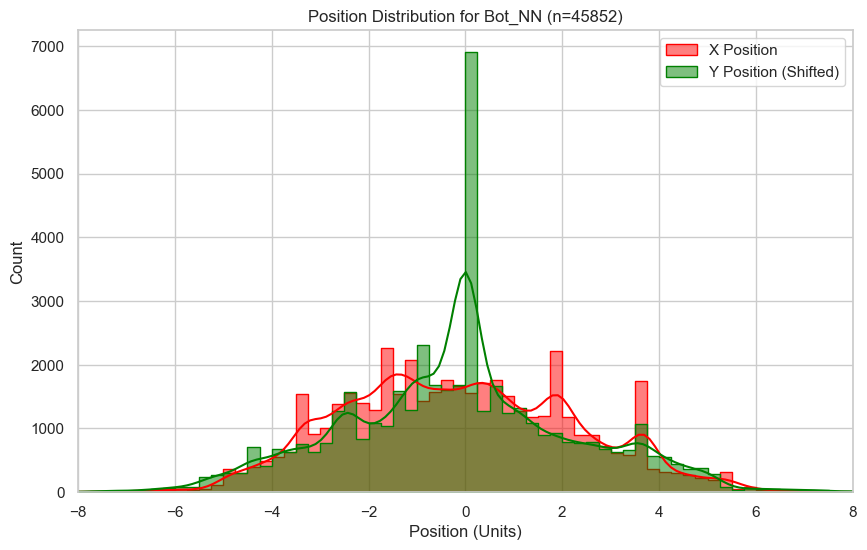

Bot_NN: 45852 samples


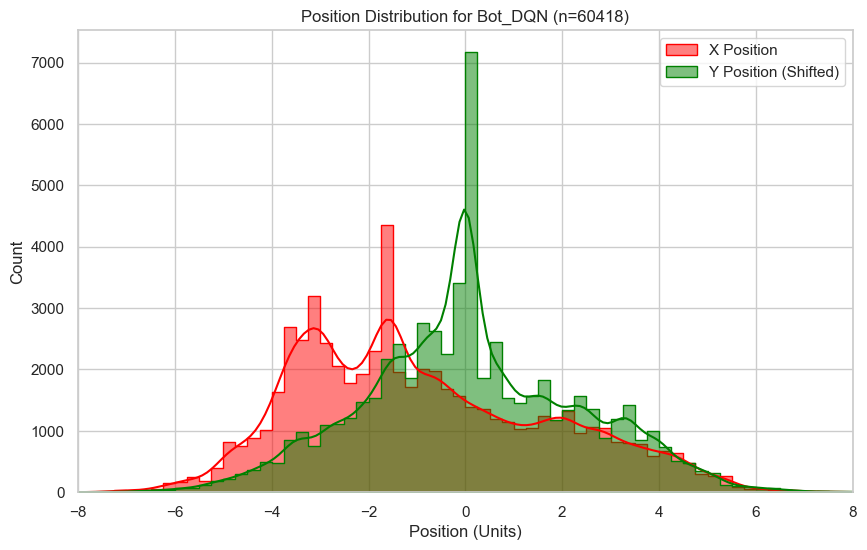

Bot_DQN: 60418 samples


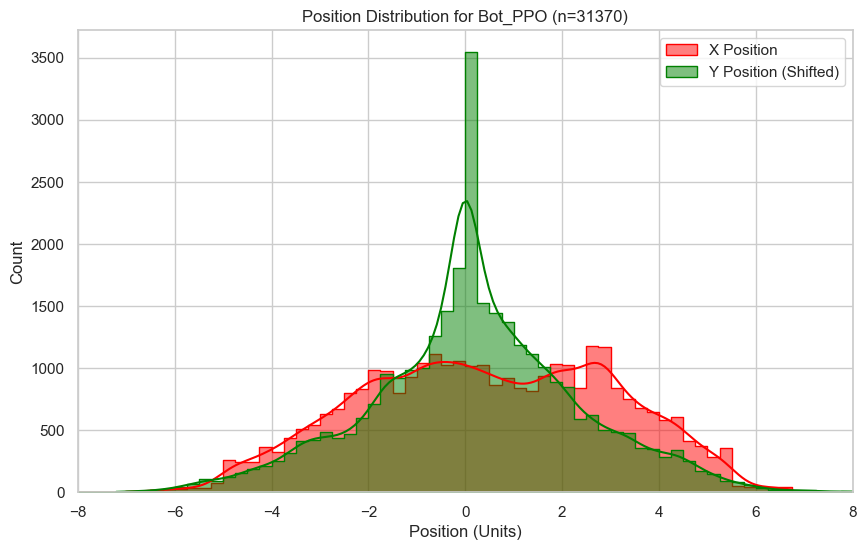

Bot_PPO: 31370 samples


In [13]:
# Position Distribution Analysis
if 'merged_df' in locals():
    # Check for necessary columns
    required_cols = ["Robot_PosX", "Robot_PosY", "Event_StartedAt", "Folder", "RoundIndex"]
    missing_cols = [c for c in required_cols if c not in merged_df.columns]
    
    if missing_cols:
        print(f"⚠️ Missing columns: {missing_cols}")
        print("Please re-run the 'Process all folders' cell and then 'Merge' cell.")
    else:
        target_bots = ["Bot_NN", "Bot_DQN", "Bot_PPO"]
        
        # 1. Prepare Data
        # Filter for target bots (Left and Right)
        mask_left = (merged_df["Event_Actor"] == "Left") & (merged_df["Meta_LeftBot"].isin(target_bots))
        df_left = merged_df[mask_left].copy()
        df_left["BotName"] = df_left["Meta_LeftBot"]
        
        mask_right = (merged_df["Event_Actor"] == "Right") & (merged_df["Meta_RightBot"].isin(target_bots))
        df_right = merged_df[mask_right].copy()
        df_right["BotName"] = df_right["Meta_RightBot"]
        
        df_pos = pd.concat([df_left, df_right])
        
        # Ensure sorted by time to find initial position correctly
        df_pos = df_pos.sort_values(["Folder", "RoundIndex", "BotName", "Event_StartedAt"])
        
        # Calculate Initial Y Position for each round to shift Y
        # We group by Round and take the first Robot_PosY
        start_y = df_pos.groupby(["Folder", "RoundIndex", "BotName"])["Robot_PosY"].first().reset_index()
        start_y.rename(columns={"Robot_PosY": "StartY"}, inplace=True)
        
        # Merge back
        df_pos = df_pos.merge(start_y, on=["Folder", "RoundIndex", "BotName"])
        
        # Apply Shift: Y_new = Y_old - Y_start
        # This makes the starting Y position 0 for all rounds
        df_pos["PosY_Shifted"] = df_pos["Robot_PosY"] - df_pos["StartY"]
        
        # Filter out first 2.5 seconds
        df_filtered = df_pos[df_pos["Event_StartedAt"] > 2.5].copy()
        
        # --- Analysis 1: Distribution of X and Y (Shifted) ---
        print("--- Position Distributions (Time > 2.5s) ---")
        
        # Consistent bins and range
        plot_range = (-8, 8)
        n_bins = 64 
        
        for bot in target_bots:
            bot_data = df_filtered[df_filtered["BotName"] == bot]
            sample_size = len(bot_data)
            
            plt.figure(figsize=(10, 6))
            
            # Plot X (Red)
            sns.histplot(data=bot_data, x="Robot_PosX", color="red", alpha=0.5, label="X Position", kde=True, element="step", binrange=plot_range, bins=n_bins)
            
            # Plot Y Shifted (Green)
            sns.histplot(data=bot_data, x="PosY_Shifted", color="green", alpha=0.5, label="Y Position (Shifted)", kde=True, element="step", binrange=plot_range, bins=n_bins)
            
            plt.title(f"Position Distribution for {bot} (n={sample_size})")
            plt.xlabel("Position (Units)")
            plt.ylabel("Count")
            plt.xlim(plot_range)
            plt.legend()
            plt.show()
            
            print(f"{bot}: {sample_size} samples")
else:
    print("merged_df not found. Please run the merge cell first.")

--- Spatiotemporal Heatmaps ---

Generating Heatmaps for Bot_NN...
  Window 2.5-15s: n=31805


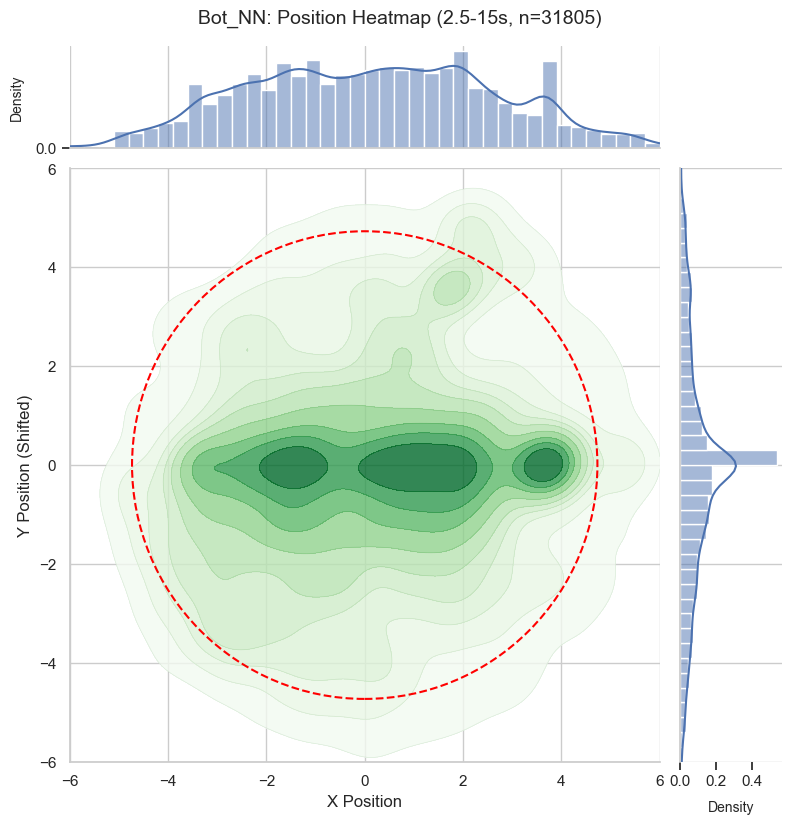

  Window 15-30s: n=7853


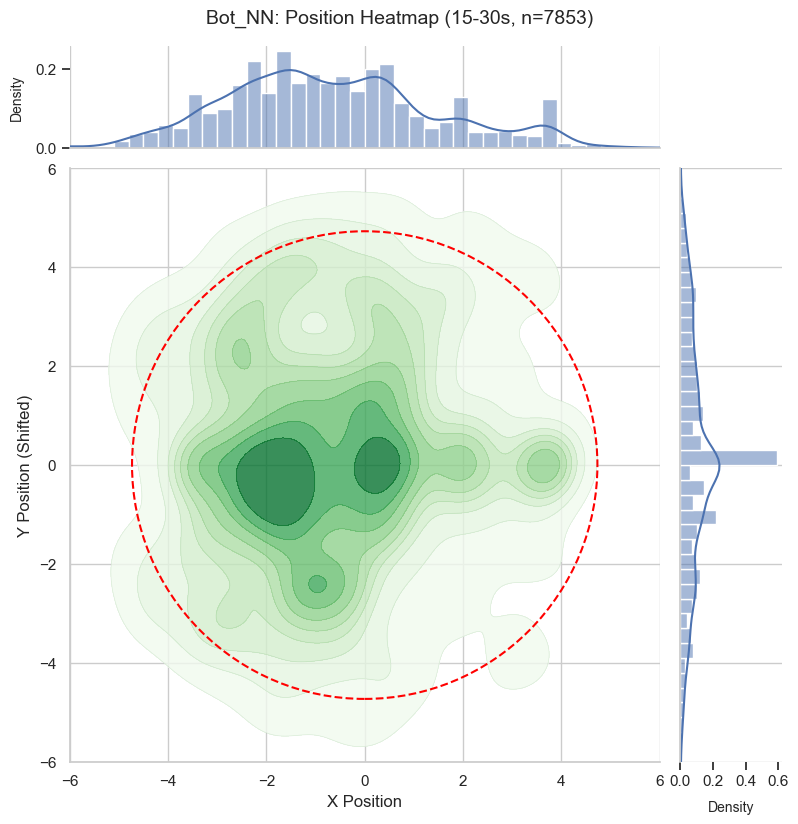

  Window 30-45s: n=3662


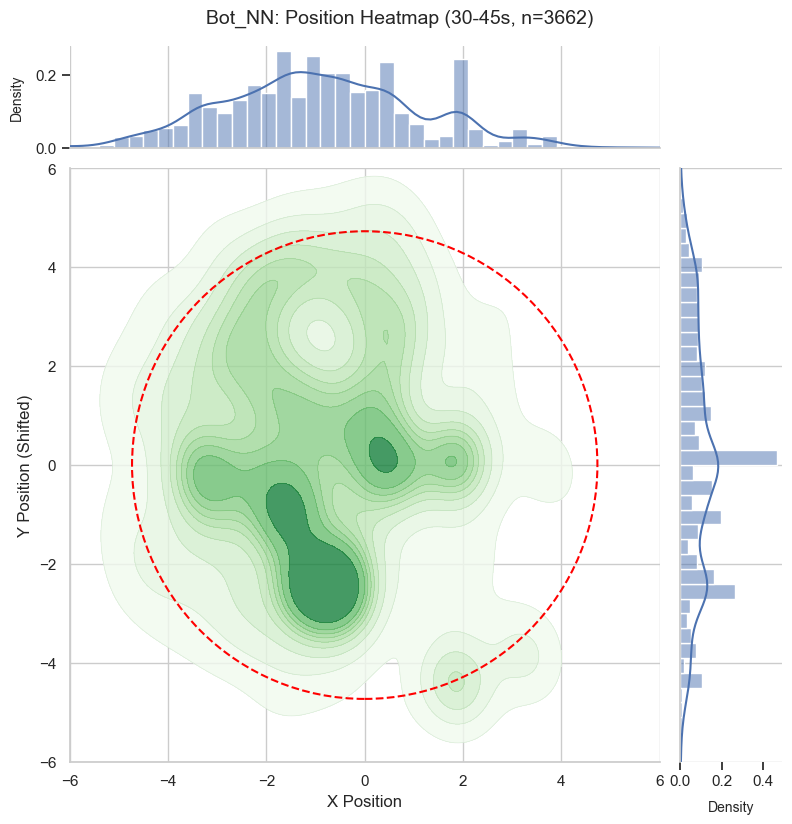

  Window 45-60s: n=2303


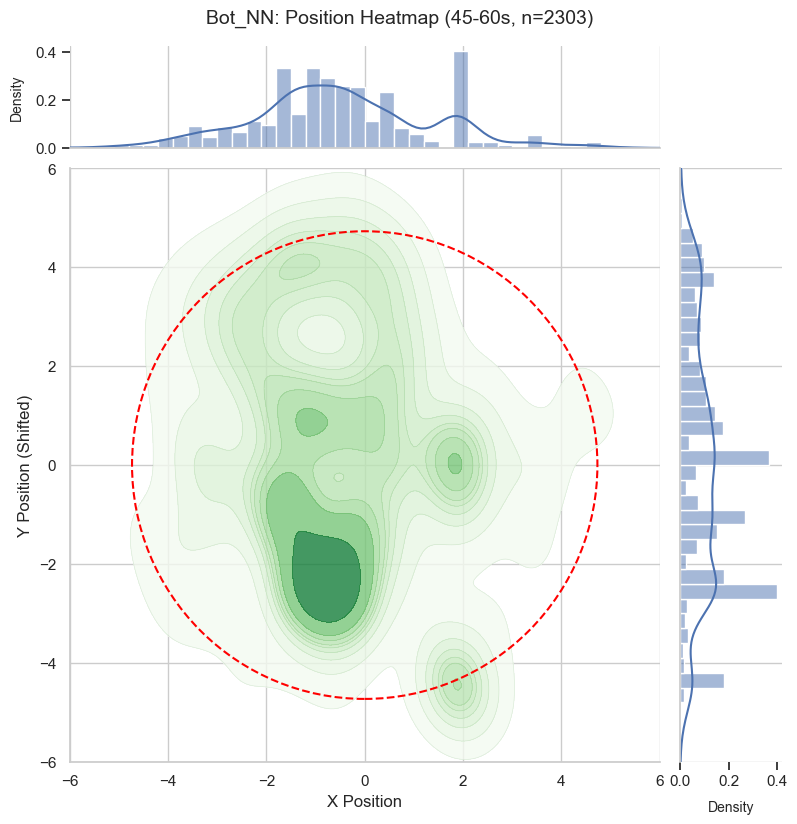


Generating Heatmaps for Bot_DQN...
  Window 2.5-15s: n=57574


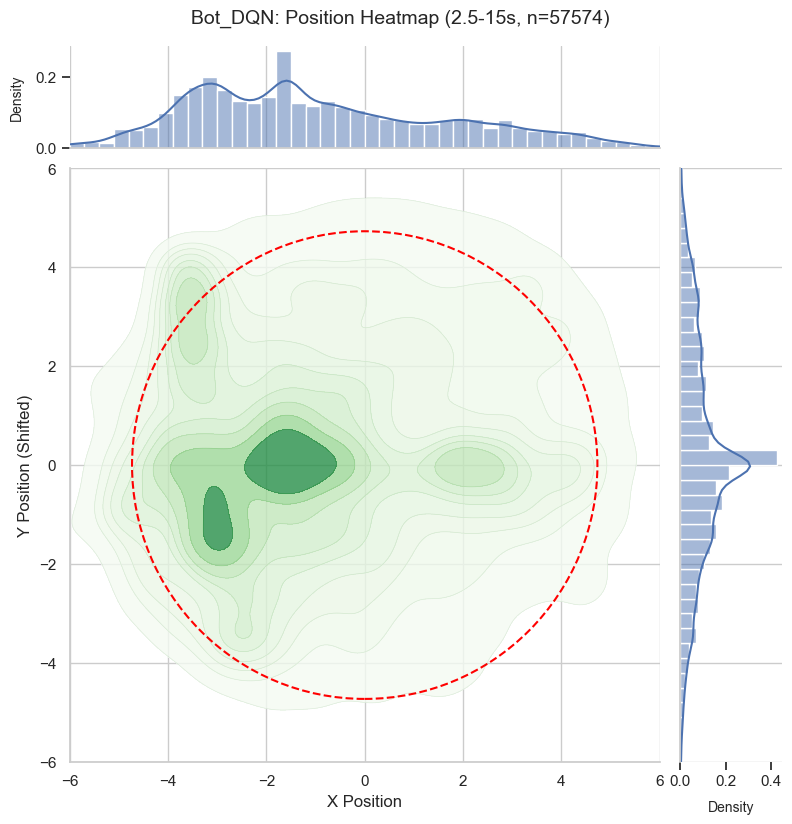

  Window 15-30s: n=2338


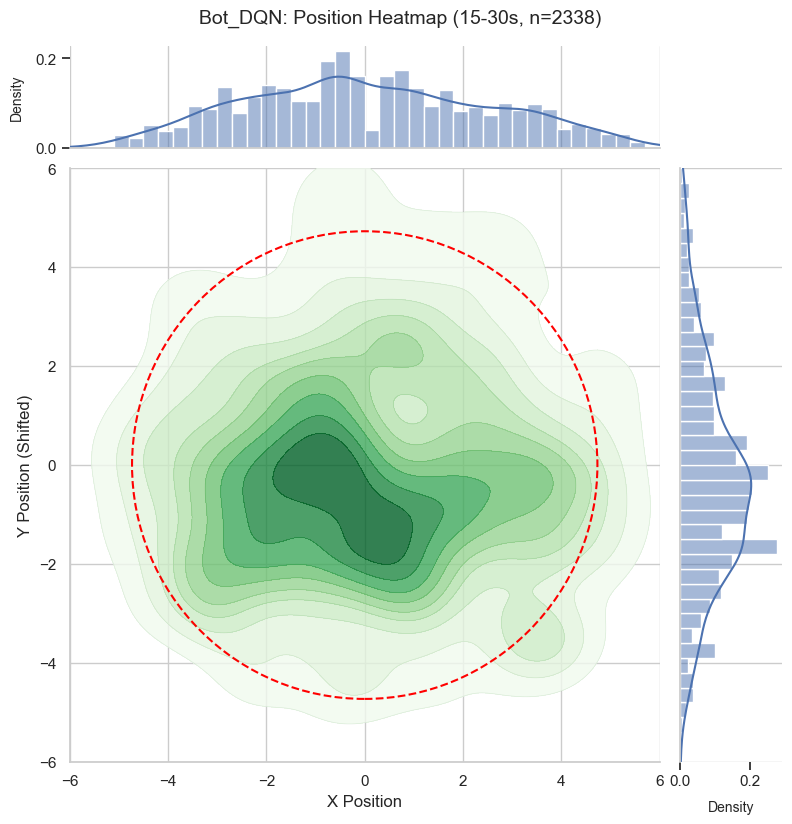

  Window 30-45s: n=405


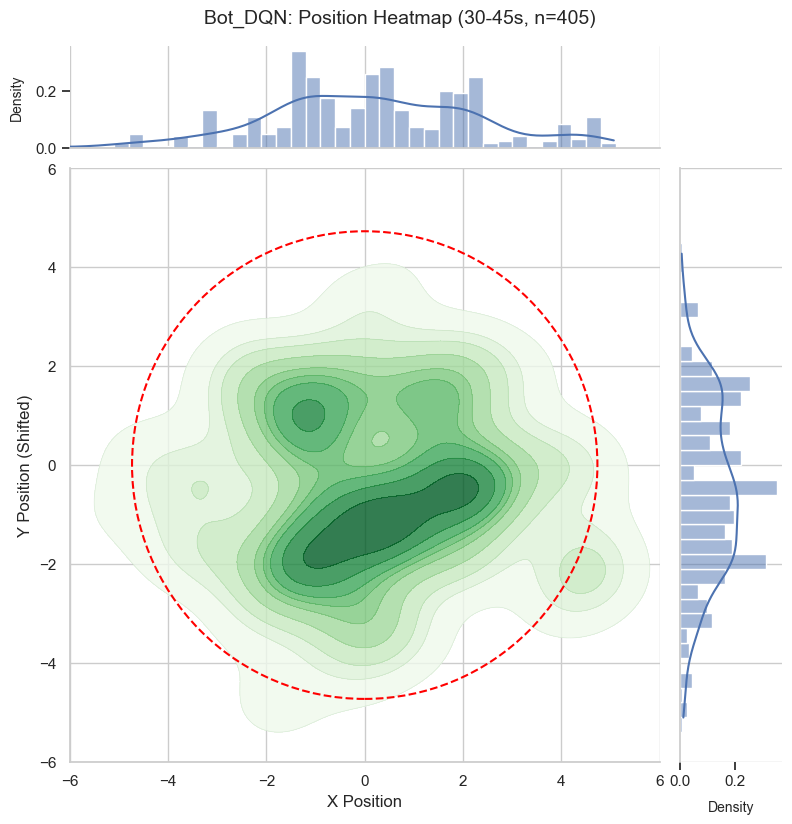

  Window 45-60s: n=86


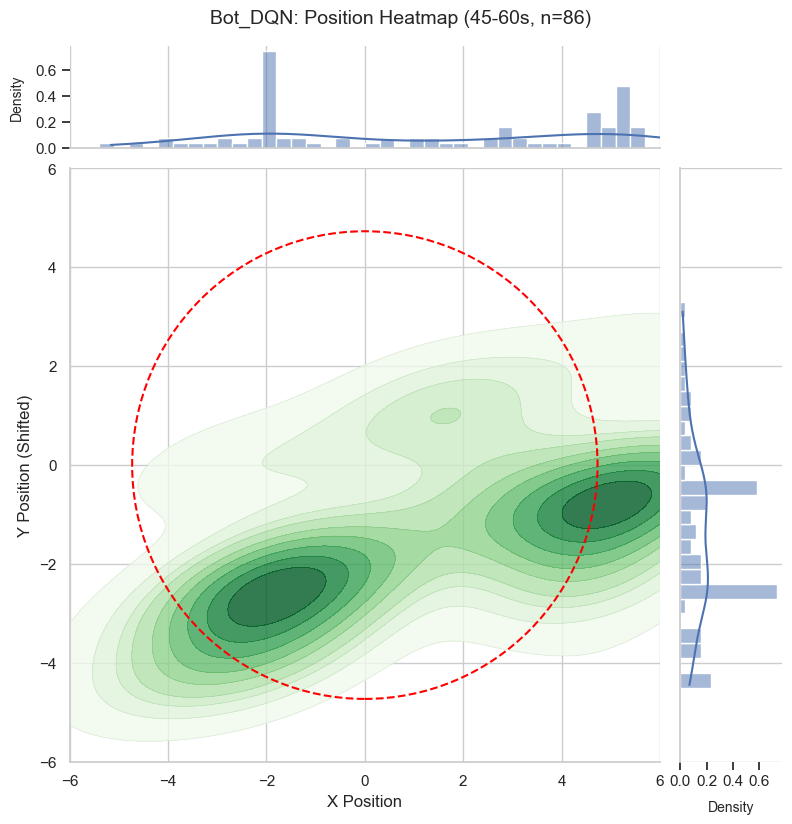


Generating Heatmaps for Bot_PPO...
  Window 2.5-15s: n=26680


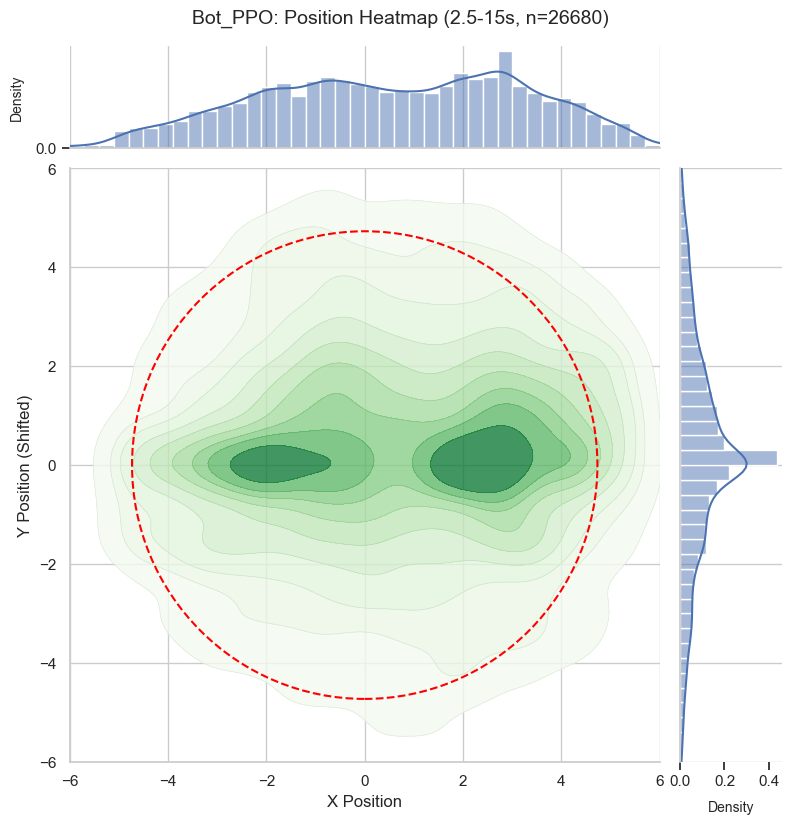

  Window 15-30s: n=3039


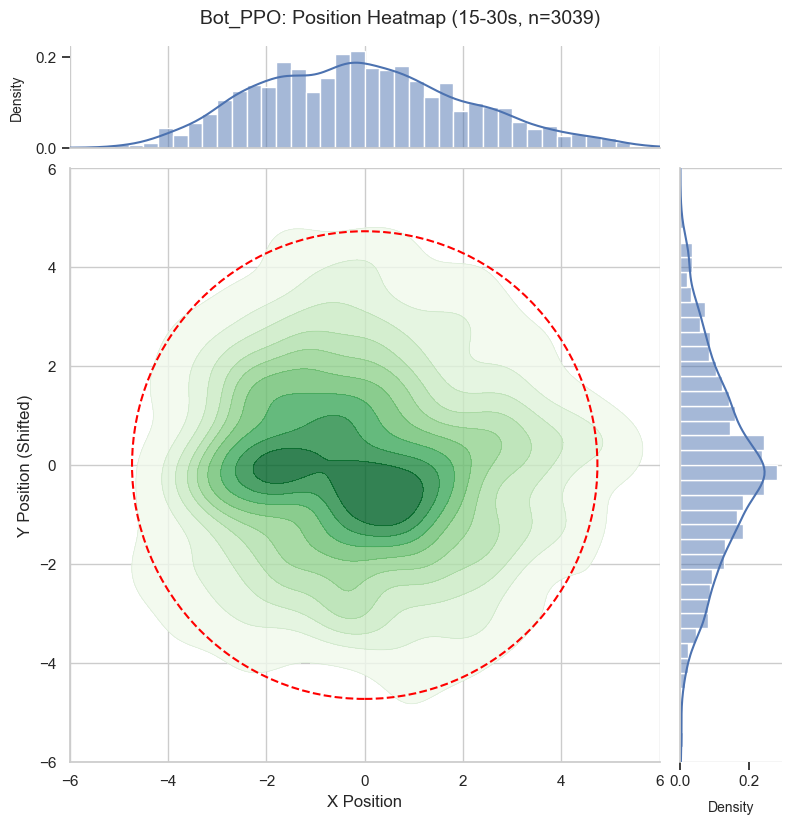

  Window 30-45s: n=1004


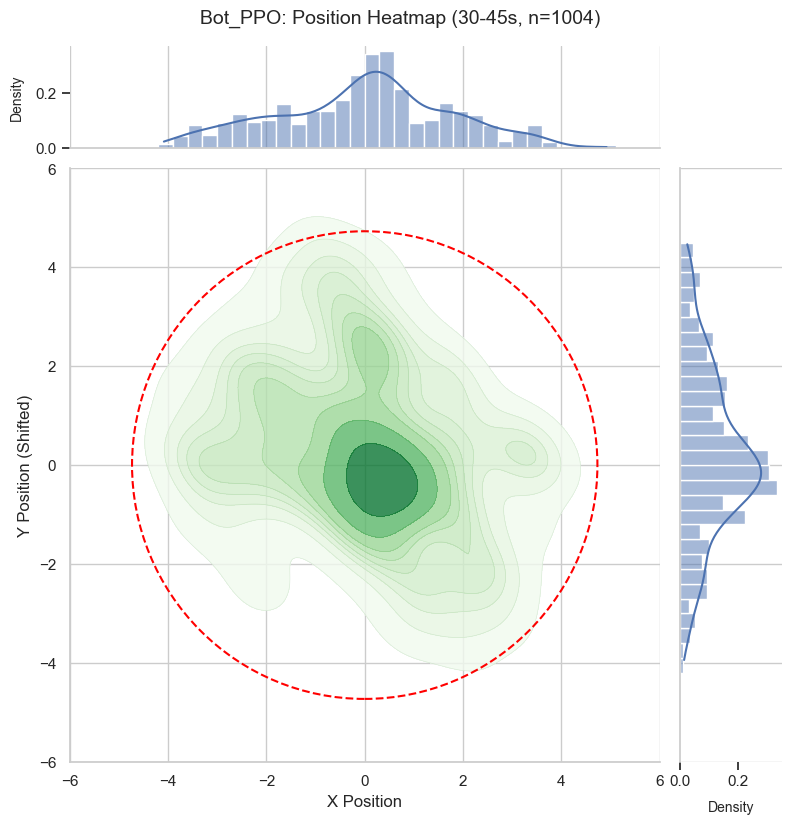

  Window 45-60s: n=520


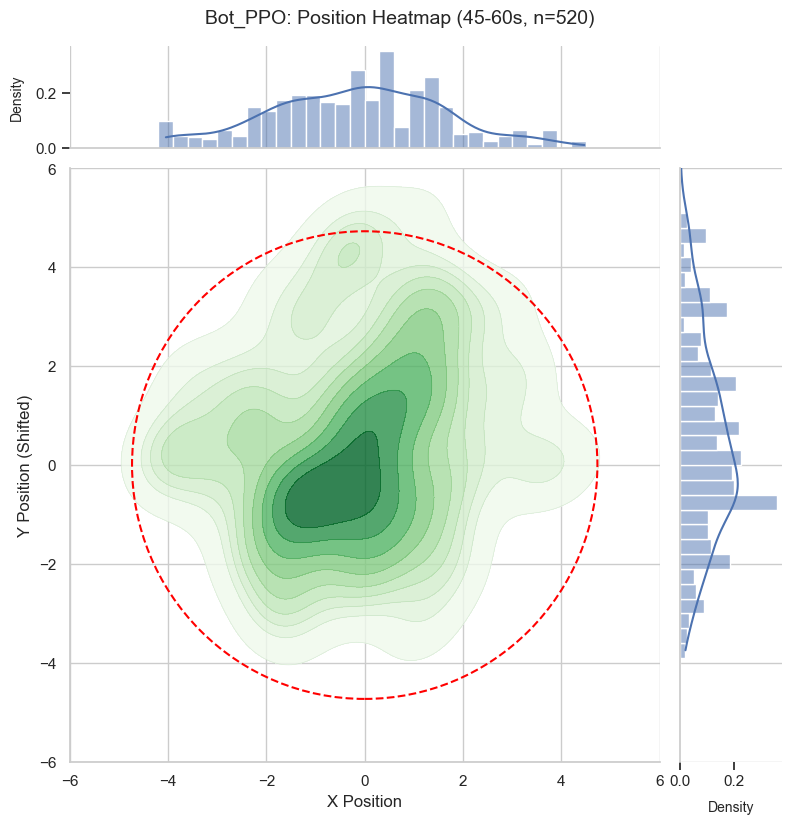

In [44]:
# Spatiotemporal Heatmaps Analysis
import matplotlib.ticker as ticker

if 'df_filtered' in locals() and 'target_bots' in locals():
    print("--- Spatiotemporal Heatmaps ---")
    
    # Define time windows
    time_windows = [(2.5, 15), (15, 30), (30, 45), (45, 60)]
    heatmap_range = (-6, 6)
    
    for bot in target_bots:
        print(f"\nGenerating Heatmaps for {bot}...")
        
        for t_start, t_end in time_windows:
            # Filter by time window
            window_data = df_filtered[
                (df_filtered["BotName"] == bot) & 
                (df_filtered["Event_StartedAt"] >= t_start) & 
                (df_filtered["Event_StartedAt"] < t_end)
            ]
            
            n_samples = len(window_data)
            
            if n_samples < 10:
                print(f"  Window {t_start}-{t_end}s: Not enough data (n={n_samples})")
                continue
            
            print(f"  Window {t_start}-{t_end}s: n={n_samples}")
            
            # Create JointGrid for Contour + Histogram
            g = sns.JointGrid(data=window_data, x="Robot_PosX", y="PosY_Shifted", height=8, xlim=heatmap_range, ylim=heatmap_range)
            
            # 1. Filled Contour (Greens)
            g.plot_joint(sns.kdeplot, fill=True, cmap="Greens", thresh=0.05, clip=heatmap_range, alpha=0.8)
            
            # 2. Outlines (Darker Green)
            g.plot_joint(sns.kdeplot, fill=False, color="darkgreen", linewidths=0.5, alpha=0.1, thresh=0.05, clip=heatmap_range)
            
            # 3. Marginals (Normalized Density)
            g.plot_marginals(sns.histplot, alpha=0.5, kde=True, stat="density", binrange=heatmap_range, bins=40)
            
            # 4. Axis Ticks and Labels for Histograms
            # --- Marginal X histogram (top): Density on Y ---
            g.ax_marg_x.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
            g.ax_marg_x.set_ylabel("Density", fontsize=10, labelpad=8)
            g.ax_marg_x.yaxis.set_label_position("left")
            g.ax_marg_x.yaxis.label.set_visible(True)
            g.ax_marg_x.tick_params(left=True, labelleft=True)

            # --- Marginal Y histogram (right): Density on X ---
            g.ax_marg_y.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
            g.ax_marg_y.set_xlabel("Density", fontsize=10, labelpad=8)
            g.ax_marg_y.xaxis.set_label_position("bottom")
            g.ax_marg_y.xaxis.label.set_visible(True)
            g.ax_marg_y.tick_params(bottom=True, labelbottom=True)

            # Set labels for main plot
            g.set_axis_labels("X Position", "Y Position (Shifted)")
            
            # Adjust layout to prevent title overlap
            g.fig.text(
                0.5, 1.0,
                f"{bot}: Position Heatmap ({t_start}-{t_end}s, n={n_samples})",
                ha="center",
                va="bottom",
                fontsize=14
            )
            
            # Add Arena boundaries (Circle)
            circle = plt.Circle((0, 0), 4.73, color='red', fill=False, linestyle='--', linewidth=1.5)
            g.ax_joint.add_patch(circle)
            
            plt.show()
else:
    print("Data not found. Please run the 'Position Distribution Analysis' cell first.")

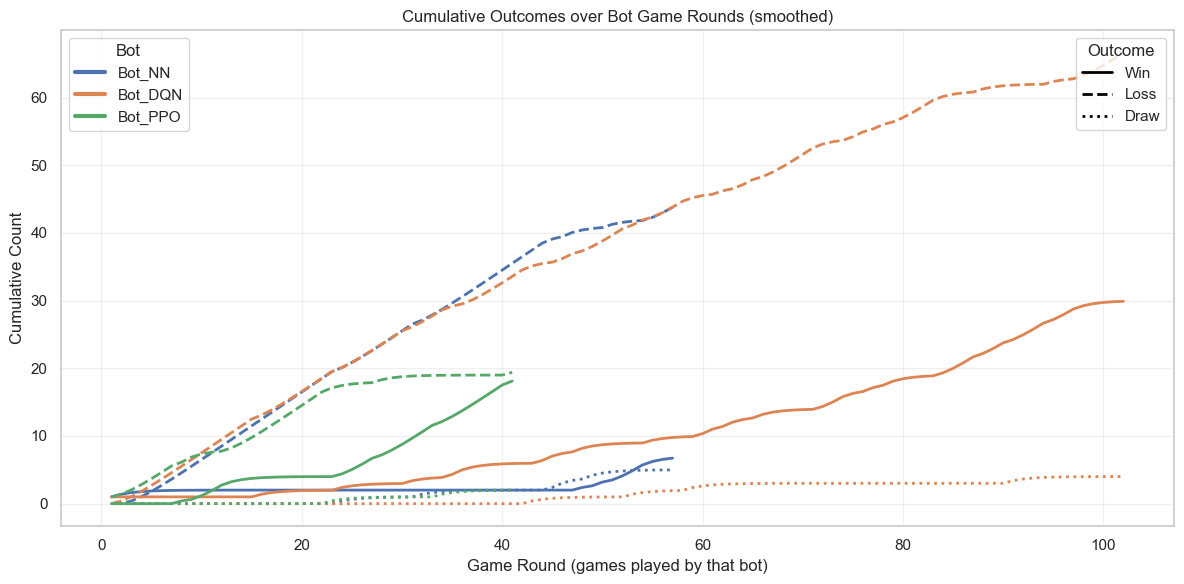

In [58]:
# === Cumulative Win/Loss/Draw over Bot Game Rounds (same plot, color=bot, linestyle=outcome, smoothed) ===
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

bots = ["Bot_NN", "Bot_DQN", "Bot_PPO"]

df = merged_df.copy()

# Parse timestamp only to get a consistent game ordering (NOT used on x-axis)
df["GameTimestamp_dt"] = pd.to_datetime(df["GameTimestamp"], format="%Y%m%d_%H%M%S", errors="coerce")

# Reduce to 1 row per game (merged_df is often per-tick/per-event)
if "BattleID" in df.columns:
    game_key = ["BattleID"]
else:
    game_key = ["GameIndex", "GameTimestamp"]

sort_cols = [c for c in ["GameIndex", "GameTimestamp_dt"] if c in df.columns]
games = (
    df.sort_values(sort_cols)
      .drop_duplicates(subset=game_key, keep="first")
      .reset_index(drop=True)
)

# Identify draw + winner bot
games["IsDraw"] = ~games["GameWinner"].isin(["Left", "Right"]) | games["GameWinner"].isna()
games["WinnerBot"] = None
games.loc[games["GameWinner"] == "Left",  "WinnerBot"] = games.loc[games["GameWinner"] == "Left",  "Meta_LeftBot"]
games.loc[games["GameWinner"] == "Right", "WinnerBot"] = games.loc[games["GameWinner"] == "Right", "Meta_RightBot"]

# ---- Plot settings ----
outcomes = {
    "Win":  {"ls": "-",  "col": "_W"},
    "Loss": {"ls": "--", "col": "_L"},
    "Draw": {"ls": ":",  "col": "_D"},
}

smooth_span = 4  # increase for smoother, decrease for more faithful steps

# Assign one consistent color per bot using matplotlib default cycle
cycle_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
bot_color = {b: cycle_colors[i % len(cycle_colors)] for i, b in enumerate(bots)}

plt.figure(figsize=(12, 6))

for b in bots:
    participated = (games["Meta_LeftBot"] == b) | (games["Meta_RightBot"] == b)
    bot_games = games[participated].copy()

    if bot_games.empty:
        print(f"[WARN] {b}: no games found in merged_df (as Meta_LeftBot/Meta_RightBot).")
        continue

    # x-axis: games played by this bot
    bot_games["BotRound"] = range(1, len(bot_games) + 1)

    win  = (bot_games["WinnerBot"] == b)
    draw = (bot_games["IsDraw"])
    loss = (~win) & (~draw)

    bot_games[f"{b}_W"] = win.astype(int)
    bot_games[f"{b}_L"] = loss.astype(int)
    bot_games[f"{b}_D"] = draw.astype(int)

    # cumulative counts over bot rounds
    bot_games[f"{b}_W_cum"] = bot_games[f"{b}_W"].cumsum()
    bot_games[f"{b}_L_cum"] = bot_games[f"{b}_L"].cumsum()
    bot_games[f"{b}_D_cum"] = bot_games[f"{b}_D"].cumsum()

    # smooth (EWMA) for "smooth lines"
    W = bot_games[f"{b}_W_cum"].ewm(span=smooth_span, adjust=False).mean()
    L = bot_games[f"{b}_L_cum"].ewm(span=smooth_span, adjust=False).mean()
    D = bot_games[f"{b}_D_cum"].ewm(span=smooth_span, adjust=False).mean()

    # plot all outcomes for this bot (same color, different line styles)
    plt.plot(bot_games["BotRound"], W, outcomes["Win"]["ls"],  color=bot_color[b], linewidth=2)
    plt.plot(bot_games["BotRound"], L, outcomes["Loss"]["ls"], color=bot_color[b], linewidth=2)
    plt.plot(bot_games["BotRound"], D, outcomes["Draw"]["ls"], color=bot_color[b], linewidth=2)

plt.title("Cumulative Outcomes over Bot Game Rounds (smoothed)")
plt.xlabel("Game Round (games played by that bot)")
plt.ylabel("Cumulative Count")
plt.grid(True, alpha=0.3)

# Two legends: one for bot colors, one for outcome linestyles
bot_handles = [Line2D([0], [0], color=bot_color[b], lw=3, label=b) for b in bots]
out_handles = [
    Line2D([0], [0], color="black", lw=2, linestyle=outcomes["Win"]["ls"],  label="Win"),
    Line2D([0], [0], color="black", lw=2, linestyle=outcomes["Loss"]["ls"], label="Loss"),
    Line2D([0], [0], color="black", lw=2, linestyle=outcomes["Draw"]["ls"], label="Draw"),
]

leg1 = plt.legend(handles=bot_handles, title="Bot", loc="upper left")
plt.gca().add_artist(leg1)
plt.legend(handles=out_handles, title="Outcome", loc="upper right")

plt.tight_layout()
plt.show()


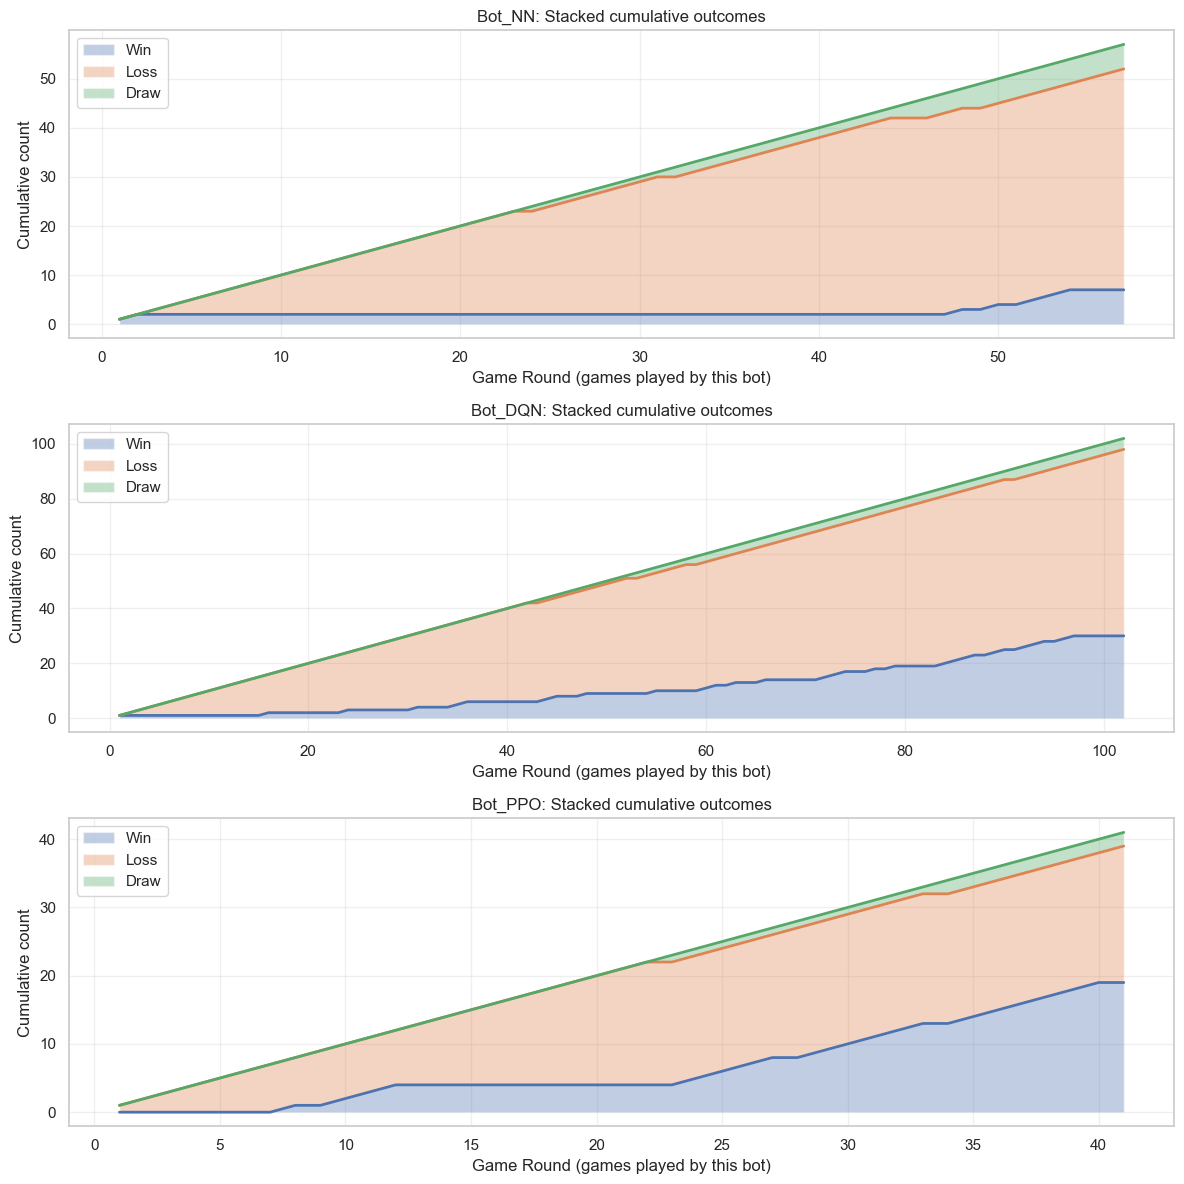

In [54]:
# === Stacked cumulative outcomes (Wins/Losses/Draws) per bot ===
import pandas as pd
import matplotlib.pyplot as plt

bots = ["Bot_NN", "Bot_DQN", "Bot_PPO"]

df = merged_df.copy()
df["GameTimestamp_dt"] = pd.to_datetime(df["GameTimestamp"], format="%Y%m%d_%H%M%S", errors="coerce")

# Reduce to 1 row per game
if "BattleID" in df.columns:
    game_key = ["BattleID"]
else:
    game_key = ["GameIndex", "GameTimestamp"]

sort_cols = [c for c in ["GameIndex", "GameTimestamp_dt"] if c in df.columns]
games = (
    df.sort_values(sort_cols)
      .drop_duplicates(subset=game_key, keep="first")
      .reset_index(drop=True)
)

# Winner / draw
games["IsDraw"] = ~games["GameWinner"].isin(["Left", "Right"]) | games["GameWinner"].isna()
games["WinnerBot"] = None
games.loc[games["GameWinner"] == "Left",  "WinnerBot"] = games.loc[games["GameWinner"] == "Left",  "Meta_LeftBot"]
games.loc[games["GameWinner"] == "Right", "WinnerBot"] = games.loc[games["GameWinner"] == "Right", "Meta_RightBot"]

# ---- Plot: one stacked chart per bot ----
fig, axes = plt.subplots(len(bots), 1, figsize=(12, 4 * len(bots)), sharex=False)
if len(bots) == 1:
    axes = [axes]

for ax, b in zip(axes, bots):
    participated = (games["Meta_LeftBot"] == b) | (games["Meta_RightBot"] == b)
    bot_games = games[participated].copy()

    if bot_games.empty:
        ax.set_title(f"{b} (no games found)")
        ax.axis("off")
        continue

    bot_games["BotRound"] = range(1, len(bot_games) + 1)

    win  = (bot_games["WinnerBot"] == b)
    draw = (bot_games["IsDraw"])
    loss = (~win) & (~draw)

    bot_games["W_cum"] = win.astype(int).cumsum()
    bot_games["L_cum"] = loss.astype(int).cumsum()
    bot_games["D_cum"] = draw.astype(int).cumsum()

    x = bot_games["BotRound"].to_numpy()
    W = bot_games["W_cum"].to_numpy()
    L = bot_games["L_cum"].to_numpy()
    D = bot_games["D_cum"].to_numpy()

    # Stacked cumulative areas:
    # base 0..W (wins), then W..W+L (losses), then W+L..W+L+D (draws)
    ax.fill_between(x, 0,   W,         alpha=0.35, label="Win")
    ax.fill_between(x, W,   W + L,     alpha=0.35, label="Loss")
    ax.fill_between(x, W+L, W + L + D, alpha=0.35, label="Draw")

    # Optional outlines (stacked "lines")
    ax.plot(x, W,           linewidth=2)
    ax.plot(x, W + L,       linewidth=2)
    ax.plot(x, W + L + D,   linewidth=2)

    ax.set_title(f"{b}: Stacked cumulative outcomes")
    ax.set_xlabel("Game Round (games played by this bot)")
    ax.set_ylabel("Cumulative count")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left")

plt.tight_layout()
plt.show()
